In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/processed/kidney_clean.csv')

In [3]:
# Always verify actual column names before referencing them —
# this dataset uses short abbreviated codes, not full words
print(df.columns.tolist())

['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


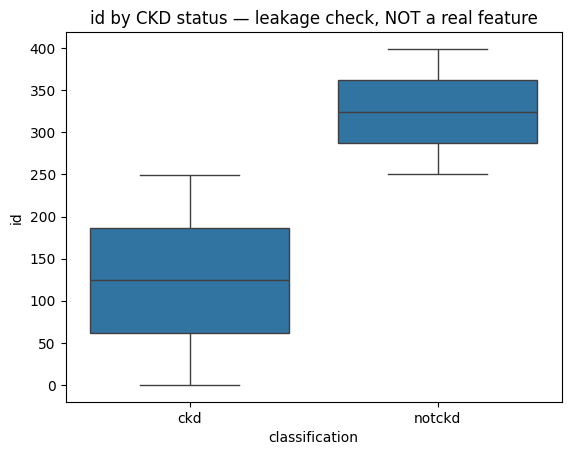

In [4]:
plt.figure()
sns.boxplot(x='classification', y='id', data=df)
plt.title('id by CKD status — leakage check, NOT a real feature')
plt.show()

In [5]:
# Drop id for modeling purposes only — keep df intact for EDA/reference
model_df = df.drop(columns=['id'])
print('id' in model_df.columns)  # should print False

False


In [6]:
df['classification'].value_counts()

classification
ckd       250
notckd    150
Name: count, dtype: int64

In [7]:
df['classification'].value_counts(normalize=True) * 100

classification
ckd       62.5
notckd    37.5
Name: proportion, dtype: float64

<Axes: title={'center': 'CKD vs Not-CKD'}, xlabel='classification'>

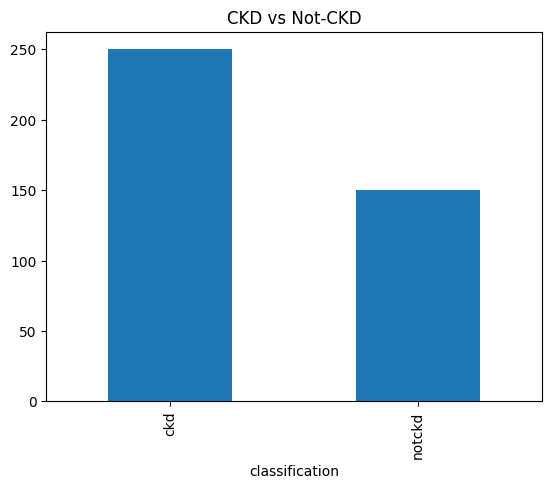

In [8]:
df['classification'].value_counts().plot(kind='bar', title='CKD vs Not-CKD')

<h2>Which Labs Differ Most Between CKD and Non-CKD</h2>

In [9]:
numeric_cols = df.select_dtypes(include='number').columns

In [10]:
# Exclude id — it's a row index, not a clinical feature
numeric_cols = [c for c in numeric_cols if c != 'id']

In [11]:
df.groupby('classification')[numeric_cols].mean()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
classification,,,,,,,,,,,,,,
ckd,54.556000,79.640000,1.014940,1.44,0.632,167.148000,70.808800,4.265400,135.246000,4.7196,11.016000,34.832000,8646.000000,4.3692
notckd,46.573333,71.466667,1.022333,0.00,0.000,108.253333,33.166667,0.883333,141.606667,4.3400,15.086667,46.166667,7719.333333,5.3520


In [12]:
from scipy import stats

In [13]:
for col in numeric_cols:
    ckd = df[df['classification']=='ckd'][col].dropna()
    notckd = df[df['classification']=='notckd'][col].dropna()
    t, p = stats.ttest_ind(ckd, notckd, equal_var=False)
    print(f"{col}: p={p:.4f}")

age: p=0.0000
bp: p=0.0000
sg: p=0.0000
al: p=0.0000
su: p=0.0000
bgr: p=0.0000
bu: p=0.0000
sc: p=0.0000
sod: p=0.0000
pot: p=0.0979
hemo: p=0.0000
pcv: p=0.0000
wc: p=0.0001
rc: p=0.0000


<h2>Boxplots/Histograms + Correlation Heatmap</h2>

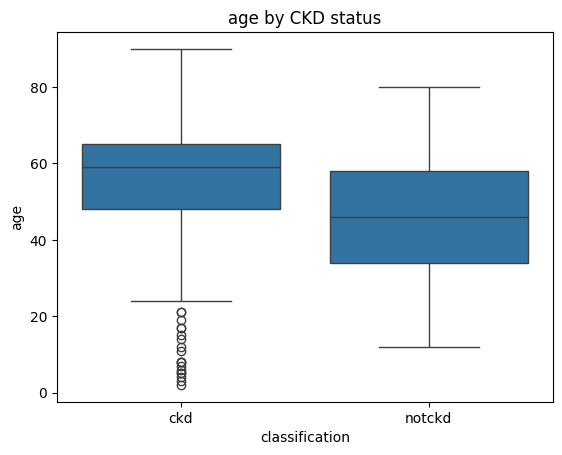

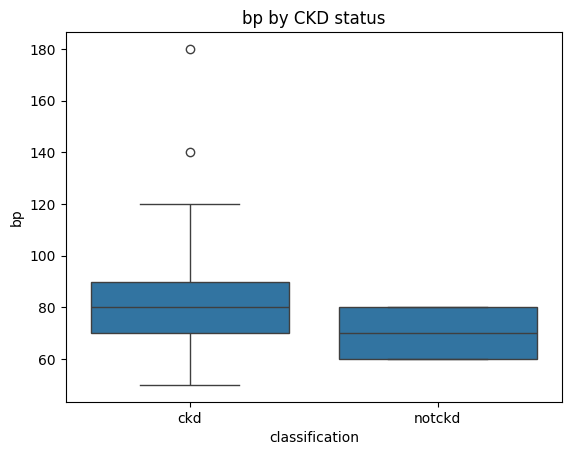

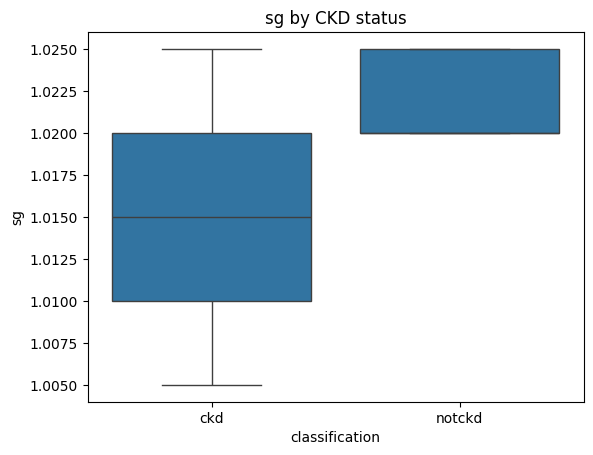

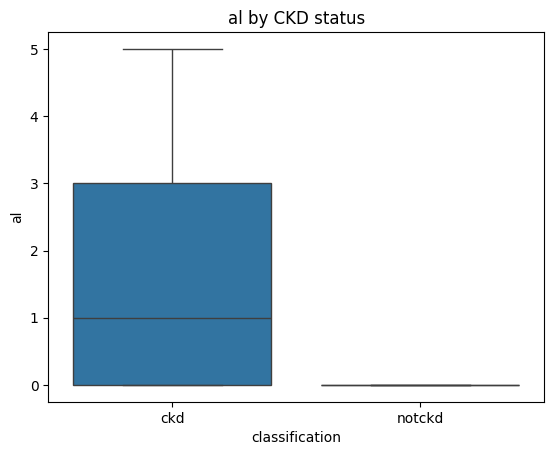

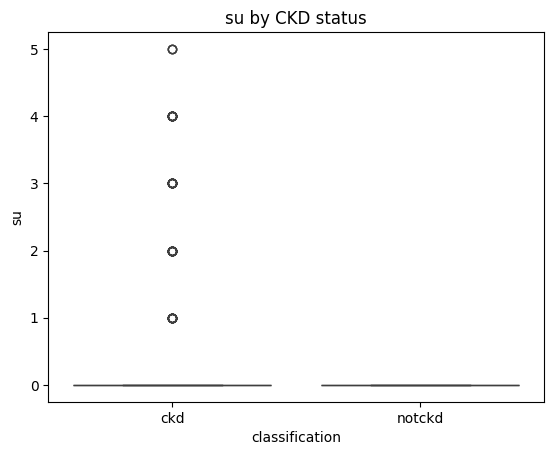

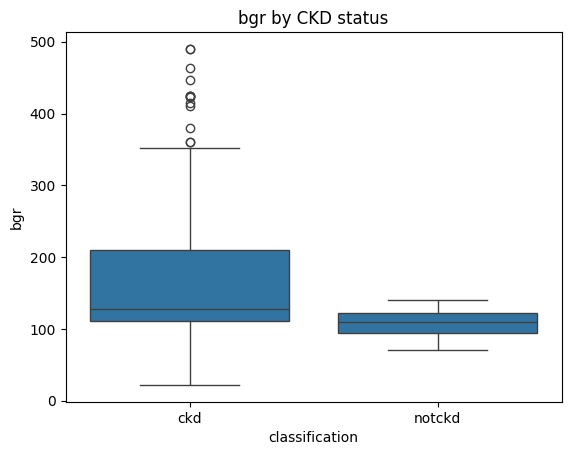

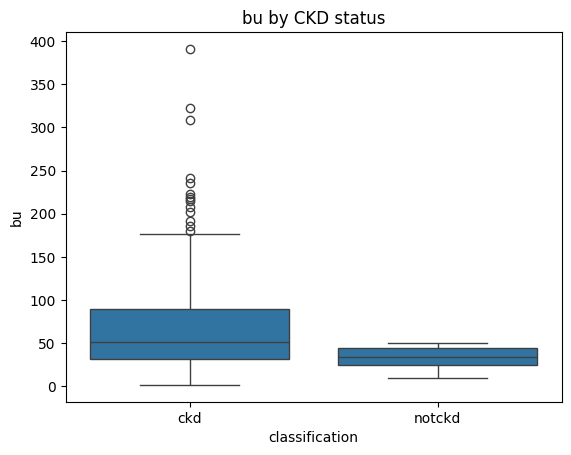

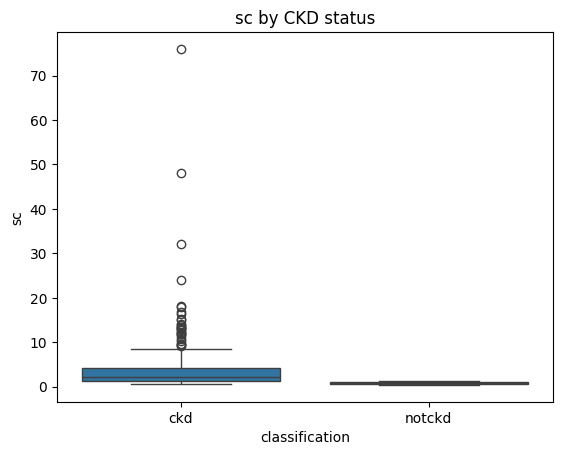

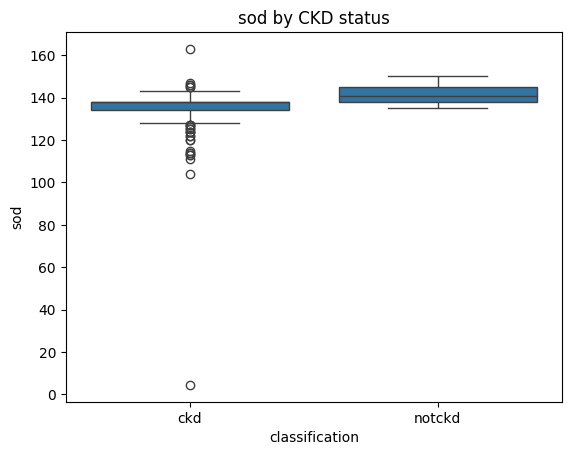

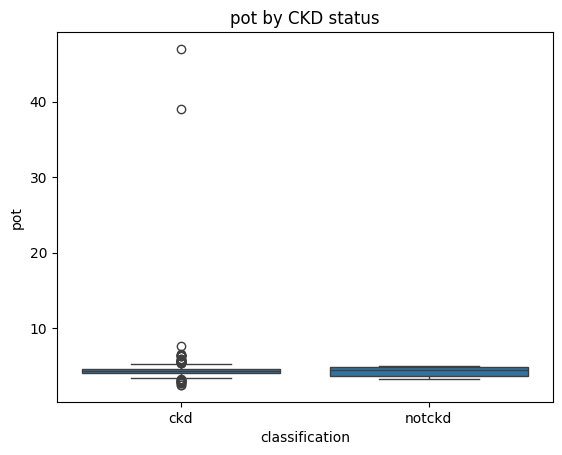

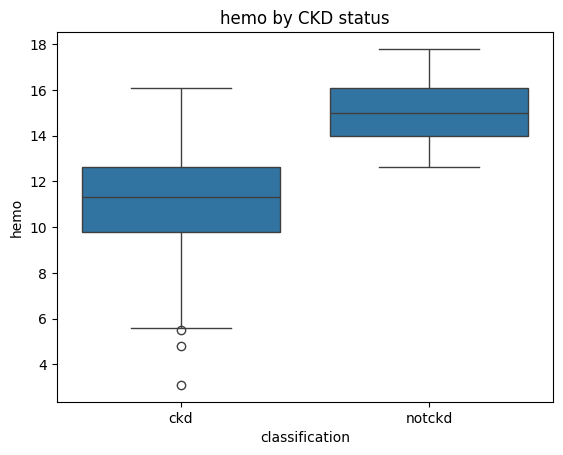

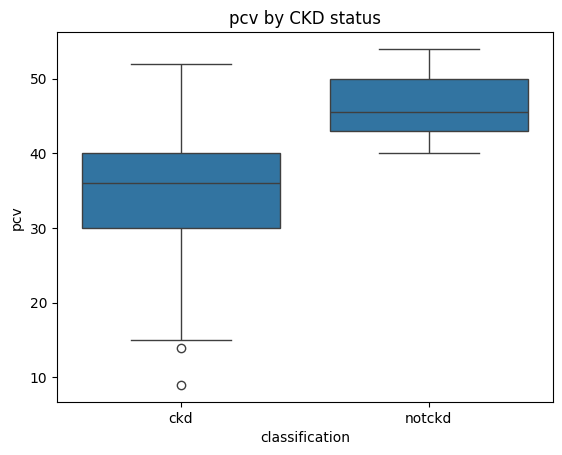

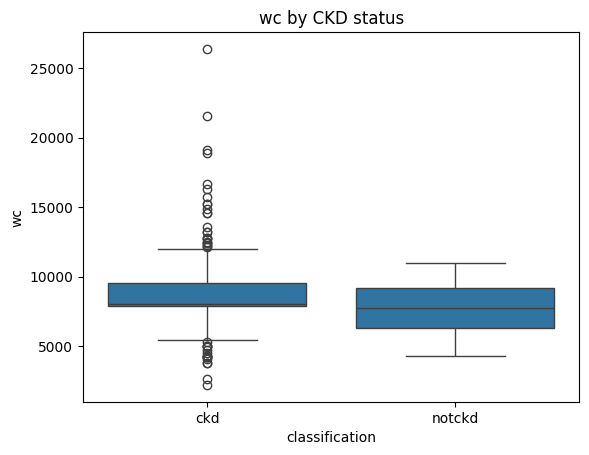

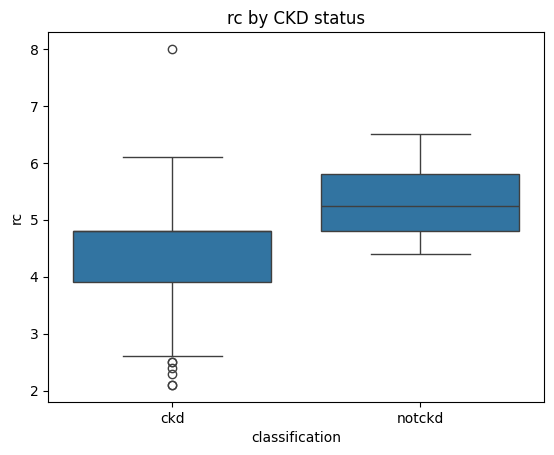

In [14]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x='classification', y=col, data=df)
    plt.title(f'{col} by CKD status')
    plt.show()


### `age` by CKD status
CKD patients skew older (median ~55–60) compared to non-CKD patients (median ~45), which is 
clinically expected since kidney function naturally declines with age and CKD prevalence 
rises with it. The CKD group also shows several low-age outliers, meaning age alone won't 
cleanly separate the classes — it's a contributing factor, not a determining one.

### `bp` (Blood Pressure) by CKD status
CKD patients show consistently higher blood pressure (median ~80 vs ~70 for non-CKD), with a 
couple of high outliers in the CKD group. This aligns with hypertension being both a cause 
and consequence of kidney disease — consistent with the `htn` cross-tab finding.

### `sg` (Specific Gravity) by CKD status
Non-CKD patients have higher and tighter specific gravity values (~1.020–1.025), while CKD 
patients show lower and more spread-out values (~1.010–1.020). Low specific gravity reflects 
the kidney's reduced ability to concentrate urine, making this one of the more clinically 
direct markers of impaired kidney function.

### `al` (Albumin) by CKD status
This is one of the most striking separators: non-CKD patients have albumin at essentially 0 
across the board, while CKD patients show a wide spread from 0 up to 5. Albumin in urine 
(albuminuria) is a hallmark clinical sign of kidney damage, so this matches medical 
expectations closely and will likely be a top feature in the model.

### `su` (Sugar) by CKD status
Non-CKD patients show almost no urine sugar, while CKD patients have a long tail of outliers 
up to 5. This likely reflects diabetic kidney disease in a subset of CKD patients rather than 
a universal CKD marker — worth checking cross-tab with `dm` (diabetes) to see if these 
outliers are the same patients.

### `bgr` (Blood Glucose Random) by CKD status
CKD patients have both a higher median (~150) and much wider spread than non-CKD patients 
(~110, tight range), with many high outliers. This reinforces the likely diabetes–CKD overlap 
already suggested by the `su` and `dm` findings — diabetes is a leading cause of CKD.

### `bu` (Blood Urea) by CKD status
CKD patients show a much higher median (~50–60) and far greater spread than non-CKD patients 
(~30, tight range), with several extreme outliers near 300–400. Elevated blood urea directly 
reflects reduced kidney filtration capacity, making this one of the strongest and most 
clinically direct CKD indicators in the dataset.

### `sc` (Serum Creatinine) by CKD status
Non-CKD patients cluster tightly near 0–2, while CKD patients show a wide spread with extreme 
outliers up to 70+. Serum creatinine is one of the primary clinical markers used to diagnose 
kidney impairment in real practice, so this feature is expected to carry major weight in the 
model — likely the single strongest predictor alongside albumin.

### `sod` (Sodium) by CKD status
Both groups show similar medians (~135–140), but CKD patients have a much wider spread and 
more low outliers, including one extreme low value. This suggests sodium imbalance appears in 
a subset of more severe CKD cases rather than being a consistent marker across all CKD 
patients.

### `pot` (Potassium) by CKD status
Medians look similar between groups, but CKD patients show several outliers, including one 
extreme value near 45 (physiologically implausible for potassium — likely a data entry error 
worth revisiting from Day 2 cleaning). Potassium regulation issues are a known CKD 
complication but this feature alone isn't a strong separator here.

### `hemo` (Hemoglobin) by CKD status
CKD patients show a clearly lower median (~11) compared to non-CKD patients (~15), with a 
tighter, more consistent distribution in the non-CKD group. This matches the well-known link 
between CKD and anemia, caused by reduced erythropoietin production from damaged kidneys — 
expect this to be a top-ranked feature.

### `pcv` (Packed Cell Volume) by CKD status
Similar pattern to hemoglobin: CKD patients show a lower median (~35) versus non-CKD (~45), 
with more spread in the CKD group. Since PCV and hemoglobin measure closely related aspects of 
blood composition, expect a high correlation between them — worth checking in the correlation 
heatmap as a candidate for feature pruning in Day 4.

### `wc` (White Blood Cell Count) by CKD status
Both groups show broadly overlapping medians (~8,000–9,000), with the CKD group showing more 
high-end outliers (up to 25,000). This suggests WBC count is a weaker, noisier separator 
compared to the kidney-specific markers above — likely reflects occasional infection/inflammation 
in some CKD patients rather than a direct kidney function signal.

### `rc` (Red Blood Cell Count) by CKD status
CKD patients show a lower median (~4) versus non-CKD (~5), consistent with the anemia pattern 
already seen in `hemo` and `pcv`. Expect meaningful correlation among these three blood-count 
features — another pruning candidate to evaluate in the correlation heatmap.

In [15]:
# Data-quality check on the pot outlier flagged in the boxplot
df[df['pot'] > 20][['pot', 'classification']]

,pot,classification
61,39.0,ckd
128,47.0,ckd


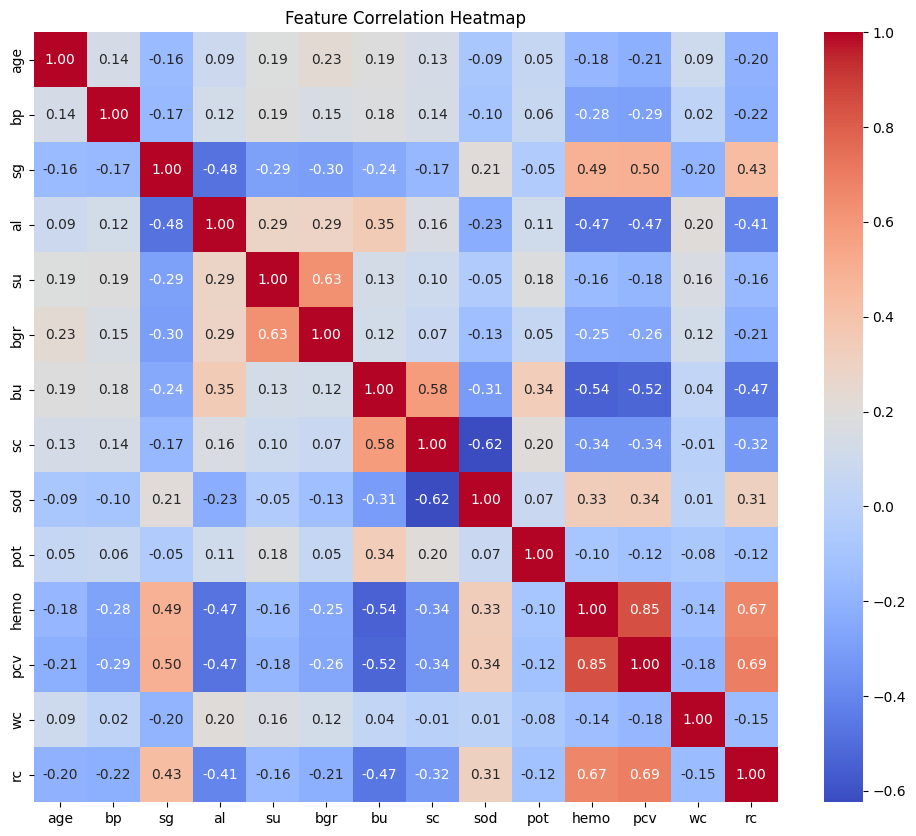

In [16]:
plt.figure(figsize=(12,10))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

## Correlation Heatmap — Interpretation

**Strongest correlations found:**

- **`hemo` ↔ `pcv`: 0.85** — by far the strongest pair in the dataset. Hemoglobin and
  packed cell volume measure closely related aspects of blood composition, so this is
  expected. **Flag as a pruning candidate for Day 4** — keeping both risks feeding the
  model two near-duplicate signals rather than genuinely new information.
- **`hemo` ↔ `rc`: 0.67** and **`pcv` ↔ `rc`: 0.69** — the same blood-count cluster
  extends to red blood cell count. All three (`hemo`, `pcv`, `rc`) move together, exactly
  as anticipated from the earlier boxplot findings on CKD-related anemia. Consider
  keeping only one or two of these three, or combining them into a single composite
  "anemia index" feature in Day 4.
- **`sc` (Serum Creatinine) ↔ `sod` (Sodium): -0.62** — a moderately strong negative
  relationship. Clinically plausible: as kidney filtration worsens (creatinine rises),
  sodium regulation often becomes impaired (sodium drops). Not necessarily redundant,
  but worth watching if both end up as top features in the model — they may be capturing
  overlapping information about kidney impairment severity.
- **`bu` (Blood Urea) ↔ `sc` (Serum Creatinine): 0.58** — both are direct markers of
  reduced kidney filtration, so a moderate positive correlation is expected. Not strong
  enough to force dropping one, but worth noting they likely contribute similar signal.
- **`su` (Sugar) ↔ `bgr` (Blood Glucose Random): 0.63** — reinforces the diabetes–CKD
  overlap already suspected from the boxplots; both reflect glycemic status rather than
  kidney function directly.

**Important secondary finding — `id` correlates with several real features:**

`id` shows notable correlation with `hemo` (0.61), `pcv` (0.57), `sg` (0.58), and `rc`
(0.50). This is **not a real relationship** — it's further confirmation of the leakage
issue already flagged: since rows were appended in class order, `id` inherits correlation
with anything that differs by class. This reinforces the earlier decision to **drop `id`
entirely from modeling** rather than treating any of these correlations as meaningful.

**Weak/non-contributing features:** `wc` (White Blood Cell Count) shows negligible
correlation with almost every other feature (all under |0.2|), consistent with its earlier
flag as the weakest, noisiest separator in the boxplot analysis — it's likely capturing
something largely independent (incidental infection/inflammation) rather than core kidney
function.

**Action items carried into Day 4:**
- Prune or combine at least one of `hemo` / `pcv` / `rc` (correlation cluster ≥ 0.67)
- Confirm `id` is fully excluded from the feature set (already actioned)
- Keep `sc`, `sod`, `bu` as separate features for now — correlation is moderate, not
  redundant enough to drop

<h2>Cross-tabs for Categorical Risk Factors</h2>

In [17]:
categorical_cols = ['htn', 'dm', 'appet', 'pe', 'ane']

In [18]:
# Sanity-check sample sizes behind the strong splits below
for col in categorical_cols:
    print(f"\n--- {col} value counts ---")
    print(df[col].value_counts())


--- htn value counts ---
htn
no     253
yes    147
Name: count, dtype: int64

--- dm value counts ---
dm
no     263
yes    137
Name: count, dtype: int64

--- appet value counts ---
appet
good    318
poor     82
Name: count, dtype: int64

--- pe value counts ---
pe
no     324
yes     76
Name: count, dtype: int64

--- ane value counts ---
ane
no     340
yes     60
Name: count, dtype: int64


In [19]:
for col in categorical_cols:
    ct = pd.crosstab(df[col], df['classification'], normalize='index') * 100
    print(ct)

classification         ckd     notckd
htn                                  
no               40.711462  59.288538
yes             100.000000   0.000000
classification         ckd     notckd
dm                                   
no               42.965779  57.034221
yes             100.000000   0.000000
classification         ckd     notckd
appet                                
good             52.830189  47.169811
poor            100.000000   0.000000
classification         ckd     notckd
pe                                   
no               53.703704  46.296296
yes             100.000000   0.000000
classification         ckd     notckd
ane                                  
no               55.882353  44.117647
yes             100.000000   0.000000


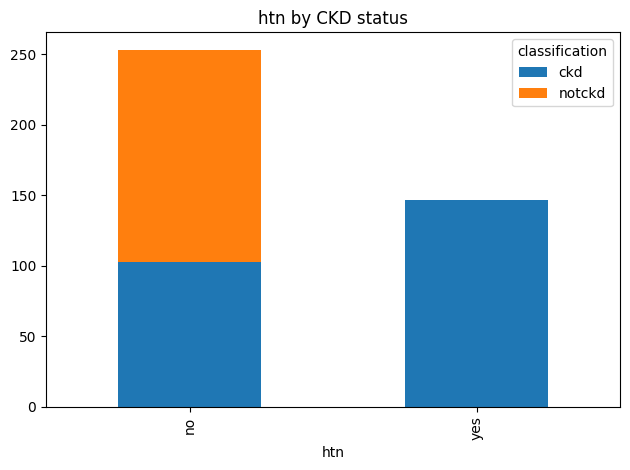

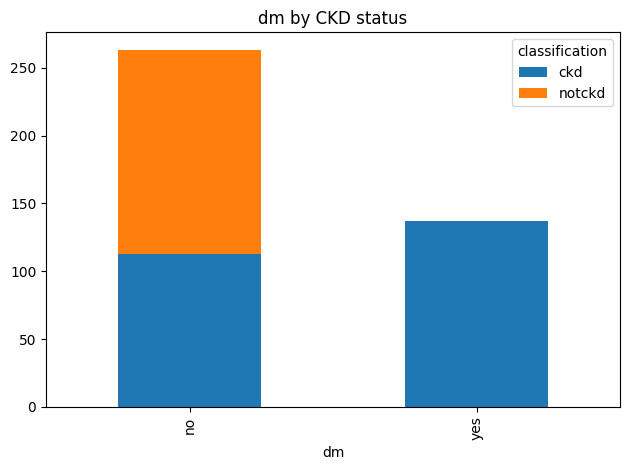

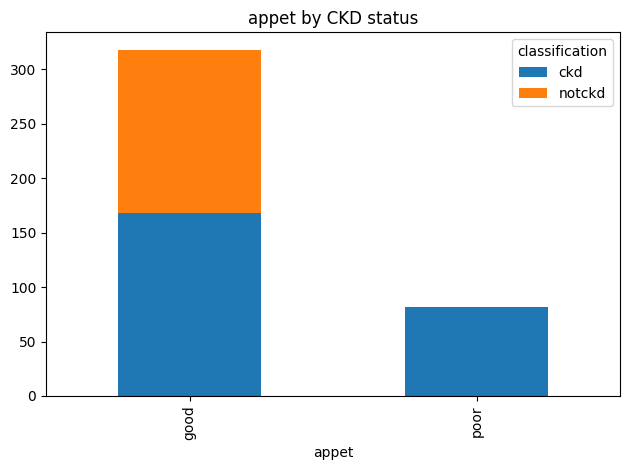

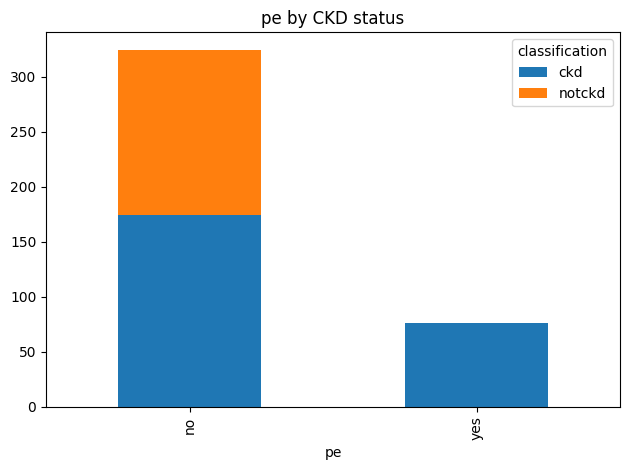

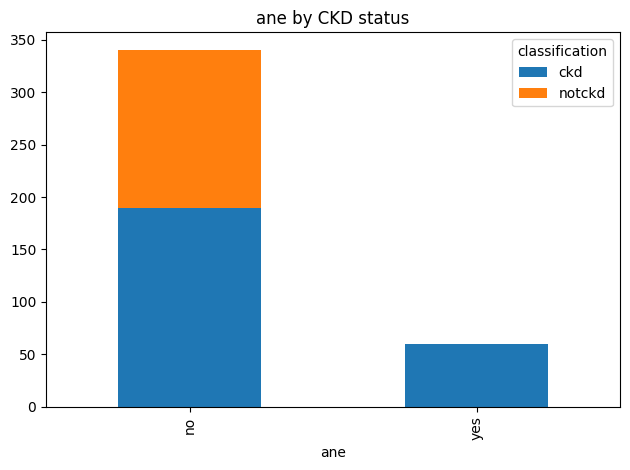

In [20]:


for col in categorical_cols:
    pd.crosstab(df[col], df['classification']).plot(kind='bar', stacked=True, title=f'{col} by CKD status')
    plt.tight_layout()
    plt.show()

## Cross-tab Stacked Bar Charts — Interpretation

**Sample-size check (addressing the earlier caution about small "yes" groups):**
Reading the bar heights, the "yes"/"poor" groups are **not trivially small** — roughly
135–145 patients for `htn`/`dm`, and 60–80 for `appet`/`pe`/`ane`. Out of 400 total
patients, that's a meaningful fraction, so the 100% CKD rate seen in each "yes" group
is a real pattern, not an artifact of a handful of cases.

**`htn` (Hypertension) — risk factor.** The "yes" bar (~145 patients) is entirely blue
(CKD) with no orange at all. The "no" group (~250 patients) splits roughly 100 CKD /
150 non-CKD. This is a strong, well-supported signal: hypertension essentially only
appears alongside CKD in this dataset, consistent with its established role as both a
cause and consequence of kidney damage.

**`dm` (Diabetes Mellitus) — risk factor.** Nearly identical pattern to `htn`: the "yes"
group (~135 patients) is entirely CKD, while the "no" group (~260 patients) splits
roughly 110 CKD / 150 non-CKD. Reinforces diabetic nephropathy as a major CKD driver in
this population.

**`appet` (Appetite) — symptom.** The "poor" group (~80 patients) is entirely CKD, while
"good" appetite (~320 patients) splits roughly 165 CKD / 155 non-CKD — much closer to
even. This fits appetite loss as a downstream consequence of advancing CKD rather than a
cause, so it shows up only once the disease is already present.

**`pe` (Pedal Edema) — symptom.** The "yes" group (~75 patients) is entirely CKD; "no"
(~320 patients) splits roughly 170 CKD / 150 non-CKD. Consistent with edema reflecting
fluid retention from reduced kidney filtration — a consequence, not a precursor.

**`ane` (Anemia) — symptom.** The "yes" group (~60 patients, the smallest of the five)
is entirely CKD; "no" (~340 patients) splits roughly 190 CKD / 150 non-CKD. Matches the
`hemo`/`pcv`/`rc` lab findings directly — anemia and CKD move together in this dataset.

**Overall pattern across all five:** Every "yes/poor" group is 100% CKD with zero
non-CKD cases. That's an unusually clean split for real clinical data — worth keeping in
mind for Day 4: these five categorical features could dominate model importance rankings
disproportionately compared to the continuous labs, simply because they're near-perfect
separators in *this specific dataset*. When you get to the model card (Day 8), it's worth
noting this as a possible dataset-specific quirk rather than assuming it will generalize
this cleanly to real-world clinical populations.